# ⚖️ Regulus — AI Governance Standards Lookup

**Describe an AI issue or system in plain language; Regulus returns the regulatory provisions that apply — across frameworks, each with a source citation, cited cross-framework references, and an optional grounded interpretation.**

Regulus is, in one line, **RAG + a knowledge network**: retrieval over *real* regulatory text, enriched by a *cited* cross-framework graph, optionally interpreted by an LLM. It is built for AI governance and model-risk work, where the question is rarely *"what text is similar?"* but *"**which requirement applies, how does it map across frameworks, and can you show me the source?**"*

It is built on the [Geometric Knowledge Network (GKN)](https://github.com/minw0607/geometric_knowledge_network).

### This notebook, step by step
1. **Setup** — imports.
2. **Configure** — choose the standards, the retriever, and describe the AI system under review.
3. **Launch** — build the system (corpus + knowledge graph + interpreter) and show basic info.
4. **Scenarios** — realistic observations/questions to test.
5. **Retrieve & answer** — applicable provisions, then a grounded, cited interpretation.
6. **Visualize** — the regulatory neighborhood of the issue.

> **Guardrail:** every provision is a real, cited unit of an official framework; cross-framework crosswalks are **curated and cited, never invented**; and the LLM **interprets — it does not author regulation**.

## 1. Setup

In [1]:
# Auto-reload edited modules; no kernel restart needed after code changes.
try:
    _ip = get_ipython(); _ip.run_line_magic('load_ext', 'autoreload'); _ip.run_line_magic('autoreload', '2')
except Exception:
    pass

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))   # make `regulus` importable

from regulus import demo
demo.ensure_gkn()   # use installed GKN, or the local sibling checkout

[setup] Using local GKN checkout at /Users/minwu/Documents/GenAI/geometric_knowledge_network/src


## 2. Configure the system

Set your choices below.

- **`STANDARDS`** — which frameworks to load (comment any out).
- **`RETRIEVER`** — `'auto'` (recommended) uses **embeddings** when your Azure/OpenAI keys are available (reused automatically from the GKN `.env`) and falls back to TF-IDF otherwise; force `'embedding'` or `'tfidf'`.
- **`TARGET_SYSTEM`** — a description of the AI system under review; the interpreter tailors its answer to it.

*Risk categories* are the seven NIST trustworthiness characteristics (valid & reliable, safe, secure & resilient, accountable & transparent, explainable, privacy-enhanced, fair) — applied automatically; to customize, edit `risk.py`.

*Retrieval quality note:* provisions are indexed as **provision-scoped units** (each with a framework/title header), not arbitrary character windows — this is what makes retrieval land on the right article. Section 3 measures it.

In [2]:
STANDARDS = [
    'eu_ai_act',      # EU AI Act — 113 articles
    'nist_ai_rmf',    # NIST AI RMF 1.0 — 72 subcategories
    'nist_ai_600_1',  # NIST AI 600-1 (GenAI Profile) — 49 action groups
    'oecd_ai',        # OECD AI Principles — 10
    'iso_42001',      # ISO/IEC 42001 — clause structure (reference)
]

# 'auto' uses embeddings when Azure/OpenAI keys are available (reused from GKN),
# else TF-IDF. Force with 'embedding' or 'tfidf'.
RETRIEVER = 'embedding'

TARGET_SYSTEM = (
    'A generative-AI customer-service assistant for a retail bank. It answers customer '
    'questions about mortgages, savings, and credit cards by retrieving from internal '
    'product documentation, and is live to the public.'
)

## 3. Launch the system

`demo.launch()` loads the chosen standards into citable provisions, builds the cited cross-framework knowledge network, and wires up the interpreter (it reuses your GKN Azure/OpenAI credentials automatically).

`overview()` is the **app card**: what Regulus is, the retrieval and generation models in use, the regulatory data store it covers, the knowledge-network structure, and its input/output contract — including the reproducibility guarantee.

In [3]:
reg = demo.launch(standards=STANDARDS, retriever=RETRIEVER, target_system=TARGET_SYSTEM)
reg.overview()

[DONE] EU AI Act: 113 provisions.
[INFO] NIST AI RMF 1.0: live parse unavailable (pypdf is required to parse the NIST AI RMF PDF (pip install pypdf).); using committed snapshot.
[DONE] NIST AI RMF 1.0: 72 provisions (snapshot).
[INFO] NIST AI 600-1 (GenAI Profile): live parse unavailable (pypdf is required to parse this PDF (pip install pypdf).); using committed snapshot.
[DONE] NIST AI 600-1 (GenAI Profile): 49 provisions (snapshot).
[INFO] OECD AI Principles: live parse unavailable (pypdf is required to parse this PDF (pip install pypdf).); using committed snapshot.
[DONE] OECD AI Principles: 10 provisions (snapshot).
[DONE] ISO/IEC 42001:2023: 16 provisions (reference snapshot).
[DONE] Loaded 260 provisions from 5 framework(s).
[INFO] faiss not installed; using NumPy exact-search fallback for the embedding index.
[INFO] Embedding mode in effect: small (model: text-embedding-3-small)
[INFO] Loading cached vector store from /Users/minwu/Documents/GenAI/geometric_knowledge_network/chec

## Regulus — AI-governance standards lookup

**What it is.** Domain-specialized GraphRAG for AI governance. You describe an AI
system and a scenario; Regulus retrieves the applicable provisions across multiple
frameworks, links them through a **cited cross-framework knowledge network**, and
(optionally) has an LLM interpret them into a grounded, cited assessment.

**Models**
- *Retrieval / embeddings:* `text-embedding-3-small` (dense) over provision-scoped units.
- *Generation (interpretation):* `gpt-5-4-20260305-gs` at temperature 0.

**Regulatory data store (260 provisions across 5 frameworks)**
  - EU AI Act — 113 provisions
  - ISO/IEC 42001:2023 — 16 provisions
  - NIST AI 600-1 (GenAI Profile) — 49 provisions
  - NIST AI RMF 1.0 — 72 provisions
  - OECD AI Principles — 10 provisions

**Knowledge network (KN) structure**
- Nodes: `Framework` → `Provision` → `RiskCategory`.
- Edges: `CONTAINS` (framework→provision), `ADDRESSES` (provision→risk),
  `CROSSWALK` (provision↔provision across frameworks — **curated & cited, never
  LLM-invented**).
- Size: 260 provisions · 67 crosswalk edges ·
  7 risk categories.

**Input** — a plain-language scenario/observation (e.g. *"our credit model was
deployed without testing for demographic bias"*), plus an optional description of
the system under review.

**Output** — a structured assessment: (1) the **risks**, (2) the **applicable
provisions** (primary + cited related provisions in other frameworks), and
(3) an **interpretation with recommended mitigants**, each grounded in a cited
provision.

**Reproducibility** — the risks and provisions are computed by code from a single
retrieval pass over a fixed data store, so the same scenario yields the **same
core** every run. Only the LLM's wording (section 3) may vary; it is labeled and
runs at temperature 0.


'## Regulus — AI-governance standards lookup\n\n**What it is.** Domain-specialized GraphRAG for AI governance. You describe an AI\nsystem and a scenario; Regulus retrieves the applicable provisions across multiple\nframeworks, links them through a **cited cross-framework knowledge network**, and\n(optionally) has an LLM interpret them into a grounded, cited assessment.\n\n**Models**\n- *Retrieval / embeddings:* `text-embedding-3-small` (dense) over provision-scoped units.\n- *Generation (interpretation):* `gpt-5-4-20260305-gs` at temperature 0.\n\n**Regulatory data store (260 provisions across 5 frameworks)**\n  - EU AI Act — 113 provisions\n  - ISO/IEC 42001:2023 — 16 provisions\n  - NIST AI 600-1 (GenAI Profile) — 49 provisions\n  - NIST AI RMF 1.0 — 72 provisions\n  - OECD AI Principles — 10 provisions\n\n**Knowledge network (KN) structure**\n- Nodes: `Framework` → `Provision` → `RiskCategory`.\n- Edges: `CONTAINS` (framework→provision), `ADDRESSES` (provision→risk),\n  `CROSSWALK` 

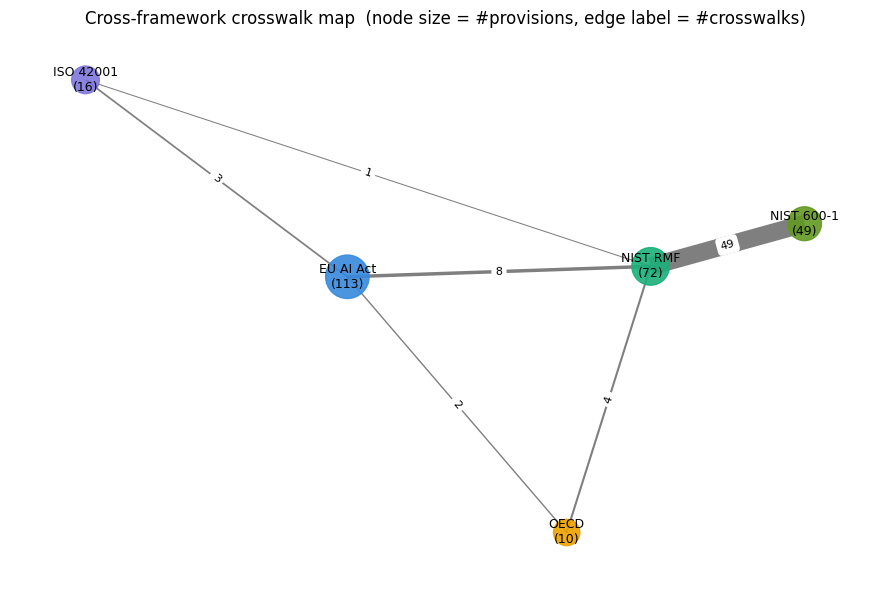

In [4]:
# The knowledge network at a glance: frameworks linked by the number of cited crosswalks.
_ = reg.framework_map()   # needs matplotlib

### Retrieval quality (does it find the right provision?)

A small labelled `issue → expected-provisions` set measures the data store — `hit` (any expected provision retrieved), `recall@k`, and `MRR`. This is how we tell whether a change to chunking or embeddings actually helps, rather than guessing. (Extend `regulus/eval.py` as coverage grows.)

In [5]:
# Retrieval quality on a small labelled eval set (hit-rate / recall@k / MRR).
demo.retrieval_report(reg, top_k=5)

,issue,hit,recall@k,mrr,top-1
0,Real-time facial recognition in public spaces ...,1.0,1.000,1.000,"EU AI Act, Article 5 — Prohibited AI practices"
1,Our credit model was deployed without testing ...,1.0,1.000,0.250,"NIST AI 600-1 (GenAI Profile), MS-2.11 — MEASU..."
2,No post-deployment monitoring of a high-risk A...,1.0,0.500,1.000,"EU AI Act, Article 72 — Post-market monitoring..."
3,Users are not told they are interacting with a...,1.0,1.000,1.000,"EU AI Act, Article 50 — Transparency obligatio..."
4,No human oversight of the model's automated de...,1.0,1.000,1.000,"EU AI Act, Article 14 — Human oversight"
5,The high-risk system was not validated for acc...,1.0,1.000,1.000,"EU AI Act, Article 15 — Accuracy, robustness a..."
6,No logging or records of the AI system's opera...,1.0,1.000,1.000,"EU AI Act, Article 12 — Record-keeping"
7,There is no risk management system for our hig...,1.0,1.000,1.000,"EU AI Act, Article 9 — Risk management system"
8,We provide no instructions for use or transpar...,1.0,1.000,1.000,"EU AI Act, Article 13 — Transparency and provi..."
9,No fundamental rights impact assessment was pe...,1.0,1.000,1.000,"EU AI Act, Article 27 — Fundamental rights imp..."


## 4. Test scenarios

Realistic, multi-issue observations. Pick one (or write your own) to run through the system.

In [6]:
# A categorized set of hypothetical scenarios (one per governance theme) lives in
# the module, so it's reusable and testable. Pick one to walk through.
from regulus import demo

for name in demo.SCENARIOS:
    print("\u2022", name)

scenario = demo.SCENARIOS['GenAI \u2014 hallucination & provenance']
print("\n" + scenario)

• Prohibited use — biometric surveillance
• Bias — credit underwriting
• Transparency — undisclosed chatbot
• Human oversight — automated decisions
• Safety & robustness — unvalidated high-risk system
• Security — adversarial & prompt injection
• Privacy — personal data governance
• Record-keeping — no logging
• Risk management — no process
• Post-market monitoring — none
• Documentation & rights impact
• GenAI — hallucination & provenance

Our generative-AI banking assistant occasionally states incorrect interest rates and invents promotional terms, and it keeps no record of which source documents supported each answer.


## 5. Assess a scenario

`reg.assess(scenario)` produces the full, **reproducible** assessment, now organized as tables:

1. **Risks, standards & controls** \u2014 each risk, the provisions (standards) that govern it, and a suggested control/mitigant (a curated, deterministic control library \u2014 *pre-built rules*, not LLM output).
2. **Priority (graph leverage)** \u2014 which provision to address *first*. This is the knowledge-network insight (see \u00a76).
3. **Cross-framework reach** \u2014 provisions the graph surfaces by following crosswalks, that similarity retrieval alone missed.
4. **Interpretation & recommended mitigants** \u2014 the LLM narrates *why* and adds scenario-specific mitigants, each grounded in a cited provision.

Pass `export=True` to save the report to `artifacts/assessments/` as Markdown + JSON + CSV (deterministic core \u2192 byte-identical across runs; only \u00a74's wording can vary).

In [7]:
# Full assessment (rendered) + saved to artifacts/assessments/
assessment = reg.assess(scenario, export=True)

## Regulus assessment
**System under review:** A generative-AI customer-service assistant for a retail bank. It answers customer questions about mortgages, savings, and credit cards by retrieving from internal product documentation, and is live to the public.
**Scenario:** Our generative-AI banking assistant occasionally states incorrect interest rates and invents promotional terms, and it keeps no record of which source documents supported each answer.

### 1. Risks, standards & controls
| risk | relevant provisions (standards) | suggested control / mitigant |
| --- | --- | --- |
| Valid and reliable | NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASURE 2.5 — generative-AI suggested actions \| NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions \| NIST AI 600-1 (GenAI Profile), MG-2.3 — MANAGE 2.3 — generative-AI suggested actions | Establish that the system performs accurately and reliably for its intended use before and after deployment. |
| Explainable and interpretable | NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE 3.2 — generative-AI suggested actions \| NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASURE 2.9 — generative-AI suggested actions | Ensure the mechanisms and meaning of outputs can be explained and interpreted for the audience. |
| Fair — with harmful bias managed | NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE 3.2 — generative-AI suggested actions \| NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASURE 2.9 — generative-AI suggested actions | Address equality/equity concerns and manage harmful bias across groups. |
| Privacy-enhanced | NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE 3.2 — generative-AI suggested actions \| NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASURE 2.9 — generative-AI suggested actions | Safeguard privacy values such as confidentiality, anonymity and data minimisation. |
| Secure and resilient | NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASURE 2.5 — generative-AI suggested actions \| NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions | Protect the system against adversarial attack and unexpected conditions, and recover gracefully. |
| Accountable and transparent | NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions | Make information and responsibility available across the lifecycle, with records that support audit. |
| Safe | NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASURE 2.5 — generative-AI suggested actions | Ensure the system does not lead to unacceptable harm under defined conditions of use. |

### 2. Priority — what to address first (graph leverage)
**Linchpin: NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions.** Highest leverage — relevant *and* the most connected provision in this scenario: it links 3 framework(s) (EU AI Act, NIST AI 600-1 (GenAI Profile), NIST AI RMF 1.0) and shares risks with 2 other finding(s). Addressing it advances the most of the rest.

| rank | provision | relevance | frameworks linked | findings connected | leverage | priority score |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions | 0.461 | 3 | 2 | 4 | 2.4145 |
| 2 | NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASURE 2.9 — generative-AI suggested actions | 0.476 | 3 | 1 | 3 | 2.0149 |
| 3 | NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASURE 2.5 — generative-AI suggested actions | 0.476 | 2 | 2 | 3 | 2.0134 |
| 4 | NIST AI 600-1 (GenAI Profile), MG-2.3 — MANAGE 2.3 — generative-AI suggested actions | 0.445 | 2 | 2 | 3 | 1.857 |
| 5 | NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE 3.2 — generative-AI suggested actions | 0.496 | 2 | 1 | 2 | 1.6004 |

### 3. Cross-framework reach (via the knowledge graph)
Related provisions the graph surfaces by following cited crosswalks — the *same concern in other frameworks*, which similarity retrieval alone did not return:

| provision (via graph) | framework | hops | path |
| --- | --- | --- | --- |
| NIST AI RMF 1.0, MANAGE 2.3 — Manage function | NIST AI RMF 1.0 | 1 | NIST AI 600-1 (GenAI Profile), MG-2.3 — MANAGE 2.3 — generative-AI suggested actions → NIST AI RMF 1.0, MANAGE 2.3 — Manage function |
| NIST AI RMF 1.0, MANAGE 3.2 — Manage function | NIST AI RMF 1.0 | 1 | NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE 3.2 — generative-AI suggested actions → NIST AI RMF 1.0, MANAGE 3.2 — Manage function |
| NIST AI RMF 1.0, MANAGE 4.1 — Manage function | NIST AI RMF 1.0 | 1 | NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions → NIST AI RMF 1.0, MANAGE 4.1 — Manage function |
| NIST AI RMF 1.0, MEASURE 2.5 — Measure function | NIST AI RMF 1.0 | 1 | NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASURE 2.5 — generative-AI suggested actions → NIST AI RMF 1.0, MEASURE 2.5 — Measure function |
| NIST AI RMF 1.0, MEASURE 2.9 — Measure function | NIST AI RMF 1.0 | 1 | NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASURE 2.9 — generative-AI suggested actions → NIST AI RMF 1.0, MEASURE 2.9 — Measure function |
| EU AI Act, Article 13 — Transparency and provision of information to deployers | EU AI Act | 2 | NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASURE 2.9 — generative-AI suggested actions → NIST AI RMF 1.0, MEASURE 2.9 — Measure function → EU AI Act, Article 13 — Transparency and provision of information to deployers |
| EU AI Act, Article 72 — Post-market monitoring by providers and post-market monitoring plan for high-risk AI systems | EU AI Act | 2 | NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions → NIST AI RMF 1.0, MANAGE 4.1 — Manage function → EU AI Act, Article 72 — Post-market monitoring by providers and post-market monitoring plan for high-risk AI systems |

### 4. Interpretation & recommended mitigants
_Generated by gpt-5-4-20260305-gs at temperature 0 (labeled, best-effort reproducible) over the exact provisions above._

## 1. **Why these provisions apply**

- **Hallucinated rates / invented promotions are a confabulation and validity problem**, so the GenAI Profile provisions on documenting confabulation, explanation results, and reliability measurement apply directly to this public-facing banking assistant that answers product questions from retrieved documentation [NIST AI 600-1 MS-2.9; NIST AI 600-1 MS-2.5].
- **The lack of records showing which source documents supported each answer is an explainability / interpretability gap**, so the provisions calling for applying and documenting ML explanation results and using XAI techniques in ongoing governance are relevant [NIST AI 600-1 MS-2.9; NIST AI 600-1 MG-3.2].
- **Because the system is live to the public and can misstate financial product terms, transparency and accountability controls are implicated**, including sharing transparency reports on steps taken to improve transparency and accountability [NIST AI 600-1 MG-4.1].
- **The issue is operational, not anecdotal**, so the provision warning against extrapolating performance from narrow or anecdotal assessments applies to how the bank evaluates this assistant’s reliability on mortgage, savings, and credit-card content [NIST AI 600-1 MS-2.5].
- **A general validity-and-reliability management provision is also implicated**, because incorrect rates and unsupported answers indicate a broader reliability management gap even though the retrieved text for this item is truncated [NIST AI 600-1 MG-2.3].

## 2. **Root cause & related provisions**

**Root governance gap:**  
The core gap is **insufficient measurement and management of confabulation plus weak answer traceability/explainability** for a public-facing GenAI system: the assistant occasionally invents product terms, and the organization cannot reconstruct what source material supported an answer [NIST AI 600-1 MS-2.9; NIST AI 600-1 MS-2.5; NIST AI 600-1 MG-3.2].

**How the related provisions reinforce this:**

- **MS-2.9 ↔ NIST AI RMF 1.0 MEASURE 2.9**: the crosswalk indicates the GenAI-specific action supports the broader AI RMF measurement subcategory, reinforcing that explanation results and confabulation-related documentation should be part of the measurement regime for this system **[related guidance; authoritative structural mapping noted in context]** [NIST AI 600-1 MS-2.9].
- **MS-2.5 ↔ NIST AI RMF 1.0 MEASURE 2.5**: this related guidance reinforces that reliability conclusions should come from systematic evaluation rather than isolated observations, which is important where errors concern regulated product information **[related guidance; authoritative structural mapping noted in context]** [NIST AI 600-1 MS-2.5].
- **MG-3.2 ↔ NIST AI RMF 1.0 MANAGE 3.2**: this related guidance extends the point from measurement into ongoing management, supporting use of XAI techniques as part of continuing control and oversight rather than one-off testing **[related guidance; authoritative structural mapping noted in context]** [NIST AI 600-1 MG-3.2].
- **MG-4.1 ↔ NIST AI RMF 1.0 MANAGE 4.1**: this related guidance reinforces that remediation of confabulation and transparency weaknesses should be communicated through transparency/accountability reporting to stakeholders **[related guidance; authoritative structural mapping noted in context]** [NIST AI 600-1 MG-4.1].
- **MG-2.3 ↔ NIST AI RMF 1.0 MANAGE 2.3**: this related guidance indicates the issue also belongs in the broader validity-and-reliability management process, though the retrieved text here is too limited to infer more specific controls **[related guidance; authoritative structural mapping noted in context]** [NIST AI 600-1 MG-2.3].

## 3. **Recommended mitigants**

- **Establish a formal confabulation test-and-document process for product answers**: systematically test prompts covering mortgages, savings, and credit cards, and document instances where the model states unsupported rates or promotional terms, because MS-2.9 explicitly calls for applying and documenting explanation results and includes confabulation documentation [NIST AI 600-1 MS-2.9].

- **Require answer-level support reconstruction using explanation methods**: for erroneous or high-risk responses, apply and document explanation techniques such as counterfactual prompts, gradient-based attributions, occlusion/term reduction, embeddings analysis, or surrogate/compression approaches to understand why the answer was produced, which directly addresses the current inability to explain support for outputs [NIST AI 600-1 MS-2.9; NIST AI 600-1 MG-3.2].

- **Move from anecdotal QA to systematic reliability evaluation**: do not rely on sporadic observations of bad answers; instead, run structured assessments across representative banking queries and document the extent to which human domain knowledge is used in evaluation, because MS-2.5 warns against extrapolating from narrow, non-systematic, anecdotal assessments [NIST AI 600-1 MS-2.5].

- **Use ongoing XAI-based monitoring as a management control**: incorporate explainability techniques into continuous monitoring and control activities so recurring patterns behind incorrect rates or invented promotions can be identified and addressed over time, consistent with MG-3.2’s direction to apply XAI techniques as part of ongoing governance [NIST AI 600-1 MG-3.2].

- **Produce and share an internal transparency report on remediation**: document what changes were made to improve transparency and accountability for this assistant—e.g., changes to evaluation, explanation/documentation practices, and confabulation handling—and share that report with relevant internal stakeholders, as MG-4.1 calls for transparency reports detailing steps taken to update the GAI system [NIST AI 600-1 MG-4.1].

- **Escalate the issue into the system’s validity-and-reliability management process**: treat incorrect rates and unsupported promotional claims as a reliability-management issue requiring tracked remediation under the organization’s broader management process, because MG-2.3 is tied to valid and reliable risk management, though the retrieved text does not provide more granular actions [NIST AI 600-1 MG-2.3].

- **Be explicit about current evidence limits**: because the retrieved context does not contain a provision expressly requiring citation logging or retrieval provenance retention, you can justify stronger explanation/documentation and confabulation controls from the cited provisions, but not claim a specific standalone obligation to retain source-document records beyond what those provisions support [NIST AI 600-1 MS-2.9; NIST AI 600-1 MG-3.2].

---
_Reproducibility: sections 1–3 are computed by code from a single retrieval pass (retriever: **embedding**, top_k=5) over a fixed data store — identical on every run for the same scenario. Only the wording of section 4 may vary._

[saved] artifacts/assessments/our-generative-ai-banking-assistant-occasionally-20260726-181648


In [8]:
# The same core as tidy DataFrames (nice for filtering / exporting elsewhere):
assessment.risk_table()

,risk,relevant provisions (standards),suggested control / mitigant
0,Valid and reliable,"NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASUR...",Establish that the system performs accurately ...
1,Explainable and interpretable,"NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE...",Ensure the mechanisms and meaning of outputs c...
2,Fair — with harmful bias managed,"NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE...",Address equality/equity concerns and manage ha...
3,Privacy-enhanced,"NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE...",Safeguard privacy values such as confidentiali...
4,Secure and resilient,"NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASUR...",Protect the system against adversarial attack ...
5,Accountable and transparent,"NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE...",Make information and responsibility available ...
6,Safe,"NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASUR...",Ensure the system does not lead to unacceptabl...


## 6. What the knowledge network adds (vs flat RAG)

Flat RAG returns the documents most *similar* to the scenario \u2014 and stops. Because similarity clusters within a framework, it tends to miss the same concern expressed elsewhere and has no notion of how its hits relate.

Regulus reads the **relationships** in the graph and turns them into insight:

- **Cross-framework reach** \u2014 follow cited crosswalks (even multi-hop) to surface related provisions in *other* frameworks that similarity never returned.
- **Leverage / linchpin** \u2014 rank provisions by relevance **\u00d7** how connected they are (frameworks linked, findings sharing risks, plus personalized-PageRank centrality). The top one is the provision to fix first: addressing it advances the most other findings.

The comparison below quantifies the difference on this scenario.

In [9]:
# Flat RAG vs Regulus GraphRAG \u2014 measured, not asserted:
_ = reg.compare_rag(scenario)

### Flat RAG vs Regulus GraphRAG — *Our generative-AI banking assistant occasionally states incorrect interest rates*

| dimension | flat RAG (similarity only) | Regulus GraphRAG |
| --- | --- | --- |
| provisions surfaced | 5 | 12 |
| frameworks covered | 1 | 3 |
| cross-framework links used | 0 | 5 |
| risks identified | 0 | 7 |
| prioritized 'address-first' | — | NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions |

_Note: leverage re-ranked the priority away from the similarity top-1 — the graph considers **NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions** the highest-impact provision to address first._

In [10]:
# The leverage ranking behind the linchpin (address-first) recommendation:
reg.priority(scenario)

,rank,provision,relevance,frameworks linked,findings connected,leverage,priority score
0,1,"NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE...",0.461,"EU AI Act, NIST AI 600-1 (GenAI Profile), NIST...",2,4,2.4145
1,2,"NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASUR...",0.476,"EU AI Act, NIST AI 600-1 (GenAI Profile), NIST...",1,3,2.0149
2,3,"NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASUR...",0.476,"NIST AI 600-1 (GenAI Profile), NIST AI RMF 1.0",2,3,2.0134
3,4,"NIST AI 600-1 (GenAI Profile), MG-2.3 — MANAGE...",0.445,"NIST AI 600-1 (GenAI Profile), NIST AI RMF 1.0",2,3,1.8570
4,5,"NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE...",0.496,"NIST AI 600-1 (GenAI Profile), NIST AI RMF 1.0",1,2,1.6004


## 7. Visualize the regulatory neighborhood

The diagram is the local map of one scenario in the knowledge network \u2014 a picture of the same facts from `assess()`:

- **Bold-outlined squares** = the *direct-hit* provisions (the primary provisions). These are what the scenario most directly implicates.
- **Plain squares** = the *cited crosswalk* provisions they link to, colored by framework \u2014 the same regulatory concern expressed in other standards.
- **Grey circles** = the *risk categories* those provisions address.

**What to take from it:** which provision is the anchor (compare with the linchpin in \u00a76), which other frameworks say the same thing (so one control satisfies several at once), and which risks are in play. A densely linked cluster is a cross-cutting issue worth prioritizing.

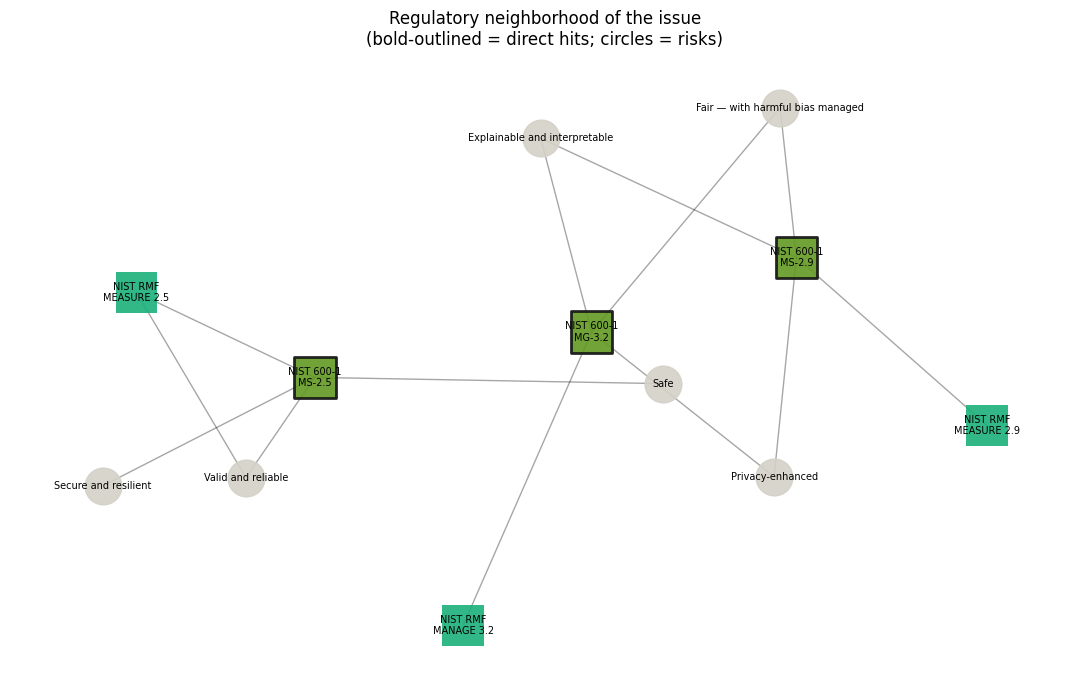

In [11]:
_ = reg.visualize(scenario, top_k=3)   # needs matplotlib

## 8. Coverage across scenarios

Run the whole categorized scenario set at once to see how well the corpus covers different governance themes \u2014 which frameworks and risk categories each scenario exercises. A quick way to spot gaps (a theme where too few frameworks or risks light up may need more crosswalks or provisions).

In [12]:
demo.coverage_report(reg)

,scenario,top provision,frameworks hit,risks identified,risk categories
0,Prohibited use — biometric surveillance,"EU AI Act, Article 5 — Prohibited AI practices",1,6,"Accountable and transparent, Fair — with harmf..."
1,Bias — credit underwriting,"EU AI Act, Article 113 — Entry into force and ...",2,7,"Accountable and transparent, Explainable and i..."
2,Transparency — undisclosed chatbot,"EU AI Act, Article 14 — Human oversight",2,5,"Accountable and transparent, Fair — with harmf..."
3,Human oversight — automated decisions,"EU AI Act, Article 6 — Classification rules fo...",1,6,"Accountable and transparent, Fair — with harmf..."
4,Safety & robustness — unvalidated high-risk sy...,"EU AI Act, Article 9 — Risk management system",2,5,"Fair — with harmful bias managed, Privacy-enha..."
5,Security — adversarial & prompt injection,"EU AI Act, Article 15 — Accuracy, robustness a...",2,7,"Accountable and transparent, Explainable and i..."
6,Privacy — personal data governance,"EU AI Act, Article 10 — Data and data governance",2,7,"Accountable and transparent, Explainable and i..."
7,Record-keeping — no logging,"EU AI Act, Article 12 — Record-keeping",1,5,"Accountable and transparent, Privacy-enhanced,..."
8,Risk management — no process,"EU AI Act, Article 9 — Risk management system",1,5,"Accountable and transparent, Privacy-enhanced,..."
9,Post-market monitoring — none,"EU AI Act, Article 72 — Post-market monitoring...",1,5,"Accountable and transparent, Fair — with harmf..."


## What's next

- **Sharper retrieval** — set `RETRIEVER = 'embedding'` above for embedding-quality context.
- **Evidence paths** — return the full trail (issue → provision → crosswalk → provision) via GKN's path explainer.
- **Measure the claim** — benchmark the graph-grounded answer against a flat-RAG baseline.
- **Interface** — a "submit an issue" web UI.

**Extend Regulus:** add crosswalk rows or frameworks under `data/`, or swap the seed crosswalks for authoritative mappings.